In [1]:
# Install yfinance — Colab doesn't have it pre-installed
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd

# Download 5 years of daily price data for Hindustan Aeronautics Ltd
ticker = "HAL.NS"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31")

# Sanity checks
print(data.shape)
data.head(10)

/tmp/ipykernel_853/1619038076.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

(1486, 5)


Price,Close,High,Low,Open,Volume
Ticker,HAL.NS,HAL.NS,HAL.NS,HAL.NS,HAL.NS
Date,,,,,
2020-01-01,307.159058,309.241283,307.074922,309.178175,6386
2020-01-02,309.283325,315.172433,306.801477,309.157135,26118
2020-01-03,309.977386,318.390397,304.340659,310.355957,277418
2020-01-06,306.864502,311.049979,303.583434,307.537532,23622
2020-01-07,309.136047,311.050002,304.971597,305.055733,15998
2020-01-08,309.409515,314.225969,303.709705,304.466871,15860
2020-01-09,309.283325,312.543367,307.874156,309.598813,17620
2020-01-10,309.788055,315.109269,307.832020,307.832020,20532


In [2]:
import numpy as np

# ── STEP 1: Flatten the multi-level column names yfinance creates ──────────
# yfinance gives columns like ("Close", "HAL.NS") instead of just "Close"
# This line simplifies them back to just: Close, High, Low, Open, Volume
data.columns = data.columns.get_level_values(0)

# ── STEP 2: TREND FEATURES ────────────────────────────────────────────────

# Daily return: how much did price move today vs yesterday (as a percentage)?
# .pct_change() divides (today - yesterday) / yesterday for every row
data["Return"] = data["Close"].pct_change()

# Simple Moving Averages: rolling average of closing price over last N days
# .rolling(N).mean() looks back N rows and averages them
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()

# How far is today's price from the 20-day average? (normalized ratio)
# > 1.0 means price is above its short-term trend (bullish)
# < 1.0 means price is below its short-term trend (bearish)
data["Price_vs_SMA20"] = data["Close"] / data["SMA_20"]

# ── STEP 3: MOMENTUM FEATURES ─────────────────────────────────────────────

# RSI — Relative Strength Index (0 to 100 scale)
# Step A: separate daily gains from daily losses
delta = data["Close"].diff()           # diff() = today's close minus yesterday's
gain = delta.clip(lower=0)             # keep only positive moves (gains), set losses to 0
loss = -delta.clip(upper=0)            # keep only negative moves (losses), set gains to 0

# Step B: compute 14-day rolling average of gains and losses
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

# Step C: RSI formula
# RS = average gain / average loss; RSI = 100 - (100 / (1 + RS))
rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

# MACD — fast moving average minus slow moving average
# .ewm() = exponential weighted mean (recent days count more than old ones)
ema_12 = data["Close"].ewm(span=12, adjust=False).mean()   # fast: 12-day EMA
ema_26 = data["Close"].ewm(span=26, adjust=False).mean()   # slow: 26-day EMA
data["MACD"] = ema_12 - ema_26                             # MACD line

# Signal line: 9-day EMA of the MACD line itself
data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

# MACD Histogram: how far apart is MACD from its signal line?
# Positive = bullish momentum building; Negative = bearish
data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

# ── STEP 4: VOLATILITY FEATURE ────────────────────────────────────────────

# 20-day rolling standard deviation of daily returns
# High value = volatile period; Low value = calm period
data["Volatility_20"] = data["Return"].rolling(20).std()

# ── STEP 5: VOLUME FEATURE ────────────────────────────────────────────────

# Today's volume divided by the 20-day average volume
# > 1.0 = unusually high volume (strong conviction behind today's move)
# < 1.0 = unusually low volume (weak conviction, possibly noise)
data["Volume_Ratio"] = data["Volume"] / data["Volume"].rolling(20).mean()

# ── STEP 6: TARGET VARIABLE ───────────────────────────────────────────────

# .shift(-1) moves the next row's value into the current row
# So: tomorrow's close is in today's row → compare with today's close
# Result: 1 if tomorrow goes up, 0 if flat or down
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

# ── STEP 7: DROP ROWS WITH NaN ────────────────────────────────────────────

# Rolling windows (20-day, 50-day) leave NaN in the first N rows
# because there aren't enough past rows to compute the average yet.
# .dropna() removes those incomplete rows entirely.
data.dropna(inplace=True)

# ── STEP 8: QUICK SANITY CHECKS ───────────────────────────────────────────

print("Shape after feature engineering:", data.shape)
print("\nColumn list:", list(data.columns))
print("\nTarget distribution (0=down, 1=up):")
print(data["Target"].value_counts())
print("\nSample of features:")
print(data[["Close", "Return", "SMA_20", "RSI", "MACD_Hist", "Volatility_20", "Volume_Ratio", "Target"]].tail(10))

Shape after feature engineering: (1437, 16)

Column list: ['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'SMA_20', 'SMA_50', 'Price_vs_SMA20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'Volatility_20', 'Volume_Ratio', 'Target']

Target distribution (0=down, 1=up):
Target
1    747
0    690
Name: count, dtype: int64

Sample of features:
Price             Close    Return       SMA_20        RSI  MACD_Hist  \
Date                                                                   
2025-12-16  4226.286133 -0.013930  4412.920728  29.295808 -12.425812   
2025-12-17  4193.558105 -0.007744  4387.343213  29.371685 -12.598412   
2025-12-18  4224.401855  0.007355  4364.676514  26.005036  -9.203626   
2025-12-19  4269.824219  0.010752  4350.310840  31.927425  -2.799482   
2025-12-22  4349.958984  0.018768  4347.385156  41.029033   7.376798   
2025-12-23  4371.083496  0.004856  4345.689258  47.711088  15.601213   
2025-12-24  4384.868652  0.003154  4340.904028  43.543680  21.667161   
2025-12-

Training rows : 1149  (2020-03-12 → 2024-10-31)
Testing rows  : 288   (2024-11-01 → 2025-12-30)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:03:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model trained successfully.

── Classification Report ──
              precision    recall  f1-score   support

    Down (0)       0.55      0.63      0.59       144
      Up (1)       0.57      0.48      0.52       144

    accuracy                           0.56       288
   macro avg       0.56      0.56      0.55       288
weighted avg       0.56      0.56      0.55       288

ROC-AUC Score : 0.5644


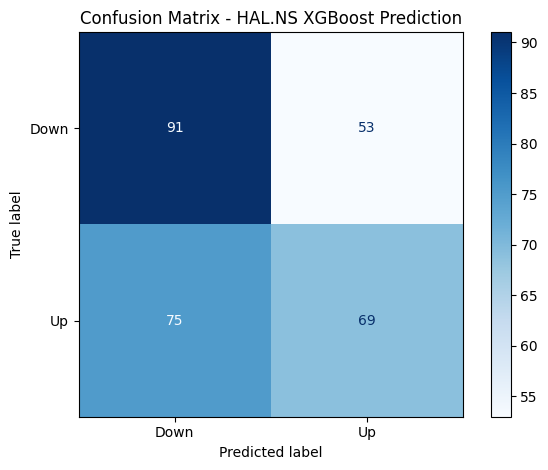

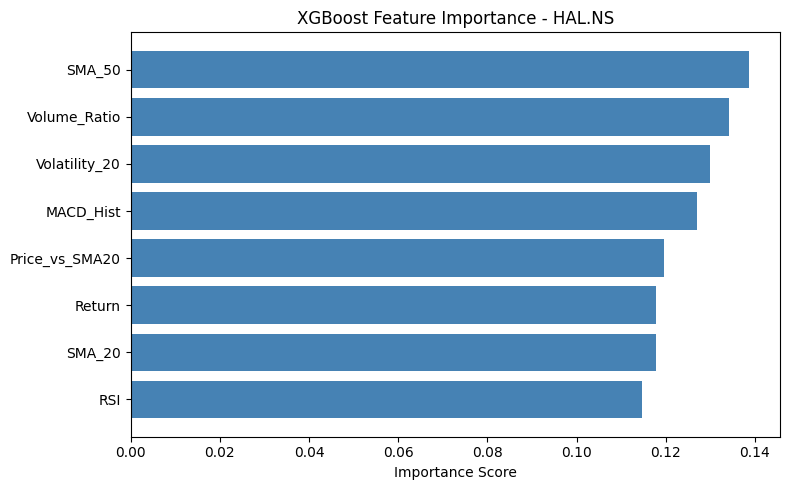

In [6]:
# Install xgboost (already on Colab, but good habit to be explicit)
# scikit-learn is pre-installed on Colab - it gives us train/test split + metrics
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt


# ── STEP 1: DEFINE FEATURES AND TARGET ────────────────────────────────────


# These are the columns we engineered in Phase 2 - the model's "inputs"
features = [
    "Return",           # today's daily return
    "SMA_20",           # 20-day moving average
    "SMA_50",           # 50-day moving average
    "Price_vs_SMA20",   # how far price is from its trend
    "RSI",              # momentum oscillator (0-100)
    "MACD_Hist",        # momentum change signal
    "Volatility_20",    # how volatile the stock has been
    "Volume_Ratio",     # is today's volume unusual?
]


X = data[features]   # feature matrix (inputs)
y = data["Target"]   # target column (what we're predicting: 0 or 1)


# ── STEP 2: CHRONOLOGICAL TRAIN/TEST SPLIT ────────────────────────────────


# Find where 80% of rows ends (chronologically, NOT randomly)
split_index = int(len(data) * 0.80)


# Everything BEFORE that index = training data (model learns from this)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]


# Everything AFTER that index = test data (we evaluate on this)
# The model has NEVER seen these dates during training
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]


print(f"Training rows : {len(X_train)}  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Testing rows  : {len(X_test)}   ({X_test.index[0].date()} → {X_test.index[-1].date()})")


# ── STEP 3: TRAIN THE XGBOOST MODEL ──────────────────────────────────────


model = XGBClassifier(
    n_estimators=200,        # number of trees (boosting rounds)
    max_depth=4,             # how deep each tree can grow (4 = moderate complexity)
    learning_rate=0.05,      # how much each new tree corrects the previous ones
                             # smaller = more careful learning, less overfitting
    subsample=0.8,           # each tree only sees 80% of training rows (adds randomness)
    colsample_bytree=0.8,    # each tree only sees 80% of features (adds randomness)
    use_label_encoder=False,
    eval_metric="logloss",   # logloss = standard metric for binary classification
    random_state=42          # reproducibility (same result every run)
)


# .fit() is where the actual learning happens
# eval_set lets us monitor performance on test data during training
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False            # set to True if you want to see training progress per tree
)


print("\nModel trained successfully.")


# ── STEP 4: MAKE PREDICTIONS ──────────────────────────────────────────────


# .predict() gives hard class labels: 0 or 1
y_pred = model.predict(X_test)


# .predict_proba() gives probabilities: [prob of 0, prob of 1] for each row
# We take column index 1 = probability that tomorrow goes UP
y_proba = model.predict_proba(X_test)[:, 1]


# ── STEP 5: EVALUATE THE MODEL ────────────────────────────────────────────


print("\n── Classification Report ──")
# Precision: of all days we predicted "up", what % actually went up?
# Recall:    of all days that actually went up, what % did we catch?
# F1:        harmonic mean of precision and recall (overall quality score)
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))


# ROC-AUC: measures how well the model ranks up-days above down-days
# 0.5 = random guessing, 1.0 = perfect, >0.55 is meaningful in finance
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score : {auc:.4f}")


# ── STEP 6: CONFUSION MATRIX ──────────────────────────────────────────────


# Shows: how many ups/downs did we correctly vs incorrectly predict?
# Rows = actual labels, Columns = predicted labels
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - HAL.NS XGBoost Prediction")
plt.tight_layout()
plt.show()


# ── STEP 7: FEATURE IMPORTANCE ────────────────────────────────────────────


# Which features did the model rely on most?
# This is a key slide/chart for your resume and portfolio README
importances = model.feature_importances_
feat_df = (
    pd.DataFrame({"Feature": features, "Importance": importances})
    .sort_values("Importance", ascending=True)  # ascending for horizontal bar chart
)


plt.figure(figsize=(8, 5))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance - HAL.NS")
plt.tight_layout()
plt.show()




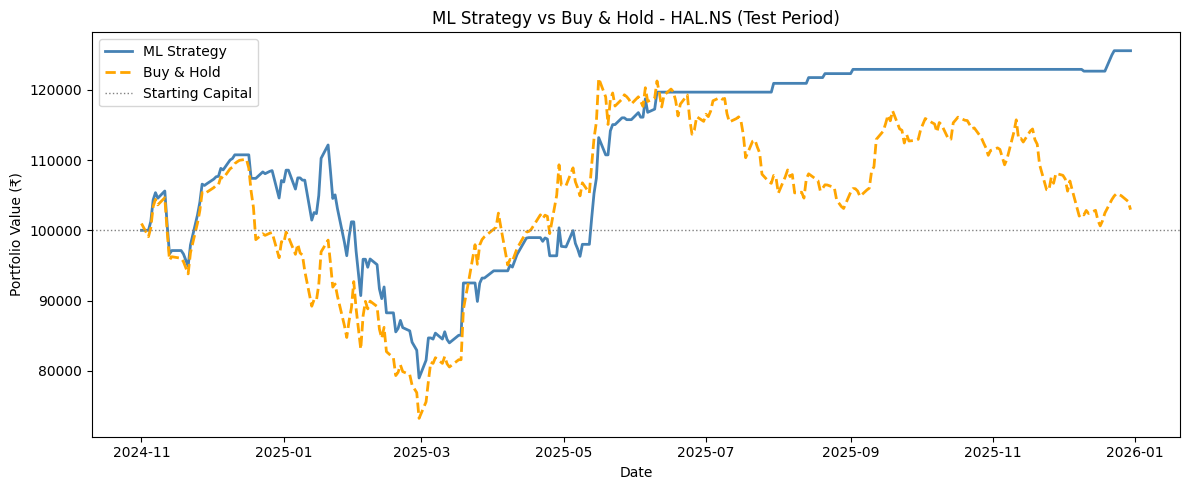

METRIC                       ML STRATEGY BUY & HOLD
Test Period                  2024-11-01 → 2025-12-30
Trading Days                        288
----------------------------------------------------
Total Return (%)                  25.6%       2.9%
CAGR (%)                          22.0%       2.6%
Sharpe Ratio                       0.92       0.24
Max Drawdown (%)                 -29.6%
Win Rate (in-market days)         56.6%
Days in Market                    122   (42%)
ROC-AUC                          0.5644


In [5]:
# ── PHASE 4: BACKTESTING ──────────────────────────────────────────────────


# We only backtest on the TEST period (dates the model never trained on)
# Using training-period predictions would be cheating (data leakage)
backtest_df = data.iloc[split_index:].copy()


# Add the model's predictions to this dataframe
# y_pred = 1 (predict up tomorrow) or 0 (predict down tomorrow)
backtest_df["Predicted"] = y_pred


# ── STRATEGY LOGIC ────────────────────────────────────────────────────────


# "Return" column = actual daily return that happened (from Phase 2)
# Strategy: on days where we predicted UP (1), we capture that day's return
#           on days where we predicted DOWN (0), we hold cash (return = 0)
# .shift(1) is critical: prediction is made at close of day T,
# so we capture the return of day T+1 (the next day's actual move)
backtest_df["Strategy_Return"] = (
    backtest_df["Predicted"].shift(1) * backtest_df["Return"]
)


# Buy-and-hold: just holds HAL every single day regardless of signal
backtest_df["BuyHold_Return"] = backtest_df["Return"]


# ── CUMULATIVE PORTFOLIO VALUE ─────────────────────────────────────────────


# Start with ₹100,000 (just a base; % returns are what matter)
initial_capital = 100_000


# (1 + daily_return).cumprod() compounds daily returns into a running total
# e.g. +1% day then -0.5% day = 1.01 × 0.995 = 1.00495 (≈ +0.5% cumulative)
backtest_df["Strategy_Value"] = (
    initial_capital * (1 + backtest_df["Strategy_Return"].fillna(0)).cumprod()
)
backtest_df["BuyHold_Value"] = (
    initial_capital * (1 + backtest_df["BuyHold_Return"].fillna(0)).cumprod()
)


# ── PLOT: PORTFOLIO VALUE OVER TIME ──────────────────────────────────────


plt.figure(figsize=(12, 5))
plt.plot(backtest_df.index, backtest_df["Strategy_Value"],
         label="ML Strategy", color="steelblue", linewidth=2)
plt.plot(backtest_df.index, backtest_df["BuyHold_Value"],
         label="Buy & Hold", color="orange", linewidth=2, linestyle="--")
plt.axhline(initial_capital, color="gray", linestyle=":", linewidth=1,
            label="Starting Capital")
plt.title("ML Strategy vs Buy & Hold - HAL.NS (Test Period)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.tight_layout()
plt.show()


# ── COMPUTE PERFORMANCE METRICS ──────────────────────────────────────────


# Total Return
strat_total_return = (backtest_df["Strategy_Value"].iloc[-1] / initial_capital - 1) * 100
bh_total_return    = (backtest_df["BuyHold_Value"].iloc[-1]  / initial_capital - 1) * 100


# Number of years in the test period (for annualizing)
n_days  = len(backtest_df)
n_years = n_days / 252   # 252 = average trading days in a year


# CAGR = Compound Annual Growth Rate
# Formula: (final_value / initial_value) ^ (1/years) - 1
strat_cagr = ((backtest_df["Strategy_Value"].iloc[-1] / initial_capital) ** (1 / n_years) - 1) * 100
bh_cagr    = ((backtest_df["BuyHold_Value"].iloc[-1]  / initial_capital) ** (1 / n_years) - 1) * 100


# Sharpe Ratio = average daily return / std dev of daily returns × sqrt(252)
# Measures return per unit of risk. >1.0 is good, >2.0 is very good.
# We subtract 0 as the risk-free rate (simplification; real Sharpe uses T-bill rate)
strat_sharpe = (
    (backtest_df["Strategy_Return"].mean() / backtest_df["Strategy_Return"].std())
    * (252 ** 0.5)
)
bh_sharpe = (
    (backtest_df["BuyHold_Return"].mean() / backtest_df["BuyHold_Return"].std())
    * (252 ** 0.5)
)


# Max Drawdown = largest peak-to-trough drop (worst losing streak)
# Formula: (current value - rolling peak so far) / rolling peak
rolling_peak = backtest_df["Strategy_Value"].cummax()
drawdown = (backtest_df["Strategy_Value"] - rolling_peak) / rolling_peak
max_drawdown = drawdown.min() * 100  # convert to percentage


# Win Rate = % of trading days where our strategy made a positive return
trading_days = backtest_df[backtest_df["Predicted"].shift(1) == 1]
win_rate = (trading_days["Strategy_Return"] > 0).mean() * 100


# Days in market vs sitting in cash
days_in_market = (backtest_df["Predicted"].shift(1) == 1).sum()
pct_in_market  = days_in_market / n_days * 100


# ── PRINT RESULTS TABLE ──────────────────────────────────────────────────


print("=" * 52)
print(f"{'METRIC':<28} {'ML STRATEGY':>10} {'BUY & HOLD':>10}")
print("=" * 52)
print(f"{'Test Period':<28} {str(backtest_df.index[0].date()):>10} → {str(backtest_df.index[-1].date())}")
print(f"{'Trading Days':<28} {n_days:>10}")
print("-" * 52)
print(f"{'Total Return (%)':<28} {strat_total_return:>9.1f}% {bh_total_return:>9.1f}%")
print(f"{'CAGR (%)':<28} {strat_cagr:>9.1f}% {bh_cagr:>9.1f}%")
print(f"{'Sharpe Ratio':<28} {strat_sharpe:>10.2f} {bh_sharpe:>10.2f}")
print(f"{'Max Drawdown (%)':<28} {max_drawdown:>9.1f}%")
print(f"{'Win Rate (in-market days)':<28} {win_rate:>9.1f}%")
print(f"{'Days in Market':<28} {days_in_market:>8}   ({pct_in_market:.0f}%)")
print(f"{'ROC-AUC':<28} {'0.5644':>10}")
print("=" * 52)


